# Traffic Object Detection: Phase 1 Preprocessing

## 1. Dataset Description and Features
**Dataset:** A curated subset of the BDD100K dataset, formatted in YOLOv8 structure via Roboflow. It focuses on diverse traffic scenarios (varying weather, lighting, and times of day) for autonomous driving and traffic monitoring.

**Features:**
In the YOLO format, labels are stored in `.txt` files corresponding to each image. The features for each detected object (row) are:
* `class_id` (Categorical): The integer representing the object type (e.g., 0 for Pedestrian, 2 for Car).
* `center_x` (Numerical): The normalized horizontal center point of the bounding box (0.0 to 1.0).
* `center_y` (Numerical): The normalized vertical center point of the bounding box (0.0 to 1.0).
* `width` (Numerical): The normalized width of the bounding box.
* `height` (Numerical): The normalized height of the bounding box.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display

labels_dir = Path("../data/train/labels")
parsed_data = []

for txt_file in labels_dir.glob("*.txt"):
    with open(txt_file, "r") as file:
        for line in file.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                parsed_data.append({
                    "class_id": int(parts[0]),
                    "center_x": float(parts[1]),
                    "center_y": float(parts[2]),
                    "width": float(parts[3]),
                    "height": float(parts[4])
                })

df = pd.DataFrame(parsed_data)

df['class_id'] = df['class_id'].astype('category')

print("Missing values in dataset:")
print(df.isnull().sum())

print(f"\nDataFrame Shape: {df.shape}")
print("\nDescriptive Statistics for Bounding Boxes:")
display(df.describe())

Missing values in dataset:
class_id    0
center_x    0
center_y    0
width       0
height      0
dtype: int64

DataFrame Shape: (140919, 5)

Descriptive Statistics for Bounding Boxes:


,center_x,center_y,width,height
count,140919.000000,140919.000000,140919.000000,140919.000000
mean,0.462460,0.455842,0.041947,0.065845
std,0.224527,0.136212,0.055870,0.078496
min,0.001563,0.003125,0.002344,0.003906
25%,0.311719,0.378125,0.012500,0.023438
50%,0.457813,0.459375,0.021875,0.039062
75%,0.600000,0.539062,0.044531,0.073438
max,0.997656,0.992969,0.857031,0.996875


In [3]:
print("Outlier Analysis")

Q1_w = df['width'].quantile(0.25)
Q3_w = df['width'].quantile(0.75)
IQR_w = Q3_w - Q1_w
lower_bound_w = Q1_w - 1.5 * IQR_w
upper_bound_w = Q3_w + 1.5 * IQR_w

Q1_h = df['height'].quantile(0.25)
Q3_h = df['height'].quantile(0.75)
IQR_h = Q3_h - Q1_h
lower_bound_h = Q1_h - 1.5 * IQR_h
upper_bound_h = Q3_h + 1.5 * IQR_h

outliers = df[
    (df['width'] < lower_bound_w) | (df['width'] > upper_bound_w) |
    (df['height'] < lower_bound_h) | (df['height'] > upper_bound_h)
]

print(f"Total objects analyzed: {len(df)}")
print(f"Found {len(outliers)} outlier bounding boxes based on width AND/OR height.")
print(f"Percentage of dataset flagged as outliers: {(len(outliers)/len(df))*100:.2f}%\n")

#Strategy
print("Outlier Handling Strategy:")
print("In the context of dashcam footage, statistical 'outliers' in width/height")
print("typically represent vehicles that are extremely close to the camera (massive boxes)")
print("or very far away on the horizon (tiny boxes).")
print("Strategy: We will KEEP these outliers in the dataset rather than removing them.")
print("Removing them would artificially blind the model to objects at extreme distances,")
print("which is critical for a robust traffic detection system.")

Outlier Analysis
Total objects analyzed: 140919
Found 17799 outlier bounding boxes based on width AND/OR height.
Percentage of dataset flagged as outliers: 12.63%

Outlier Handling Strategy:
In the context of dashcam footage, statistical 'outliers' in width/height
typically represent vehicles that are extremely close to the camera (massive boxes)
or very far away on the horizon (tiny boxes).
Strategy: We will KEEP these outliers in the dataset rather than removing them.
Removing them would artificially blind the model to objects at extreme distances,
which is critical for a robust traffic detection system.


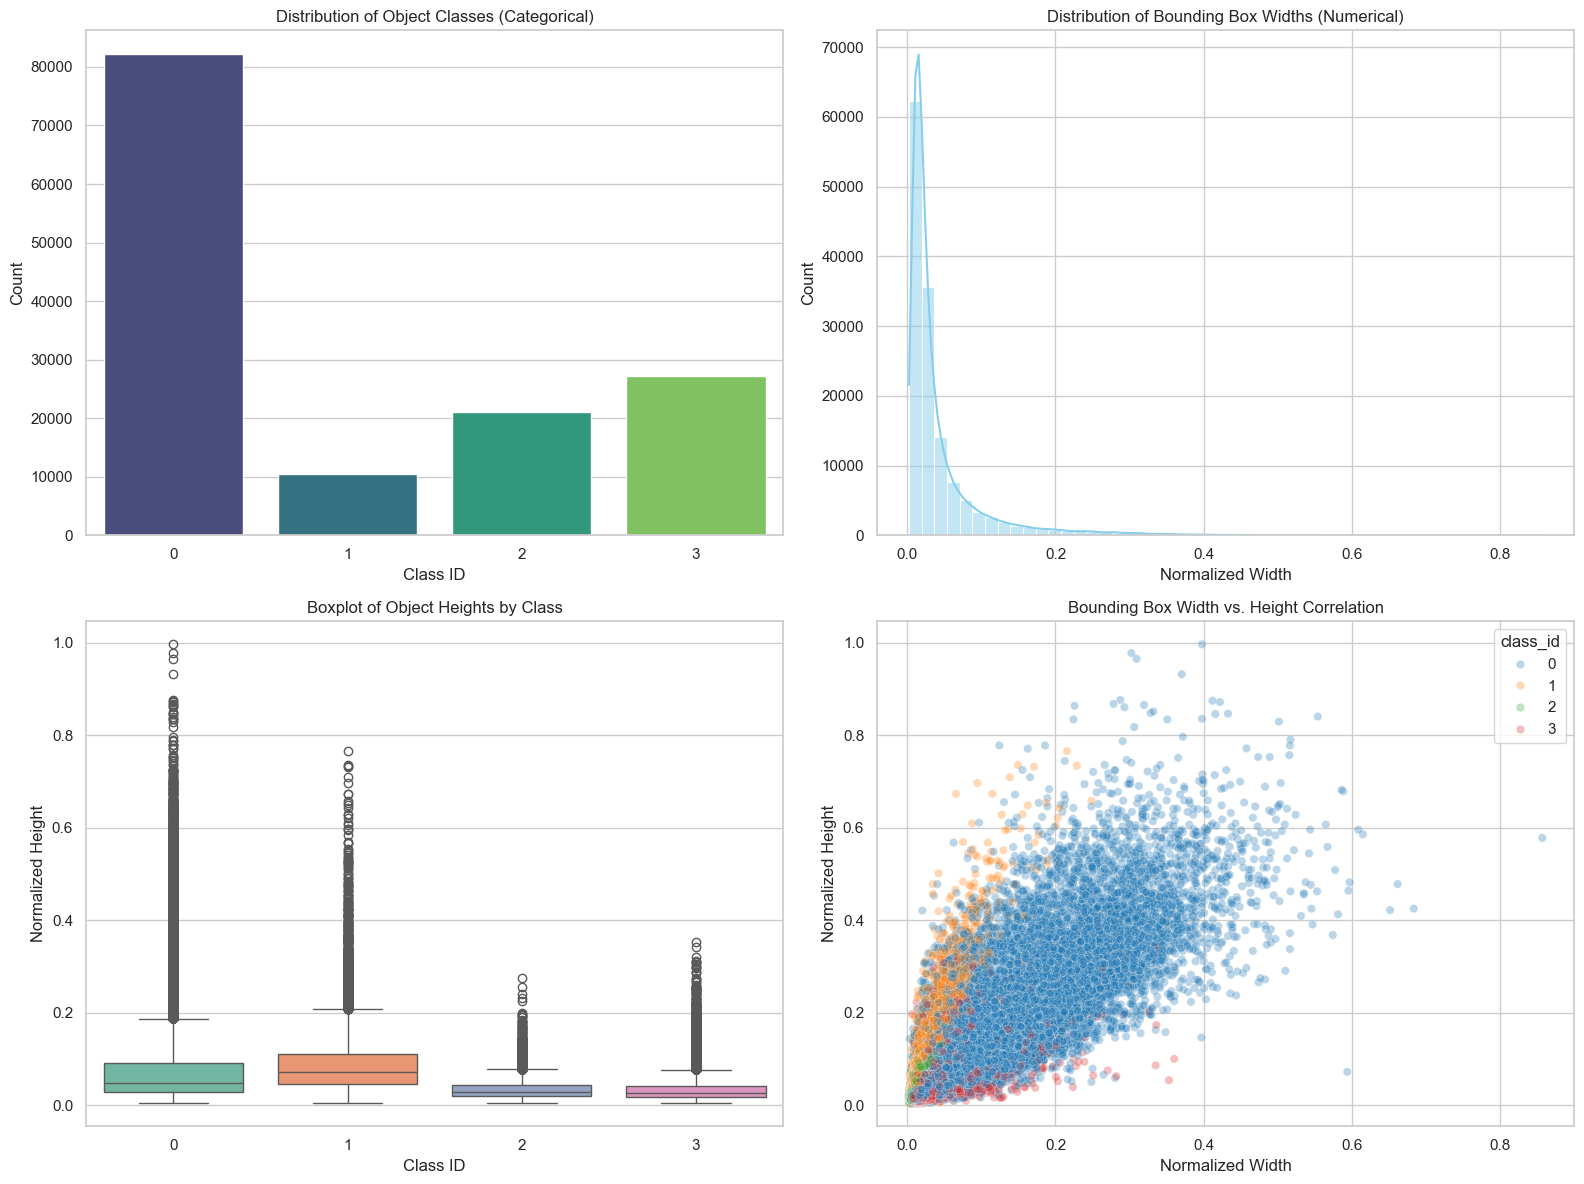


Pairplot


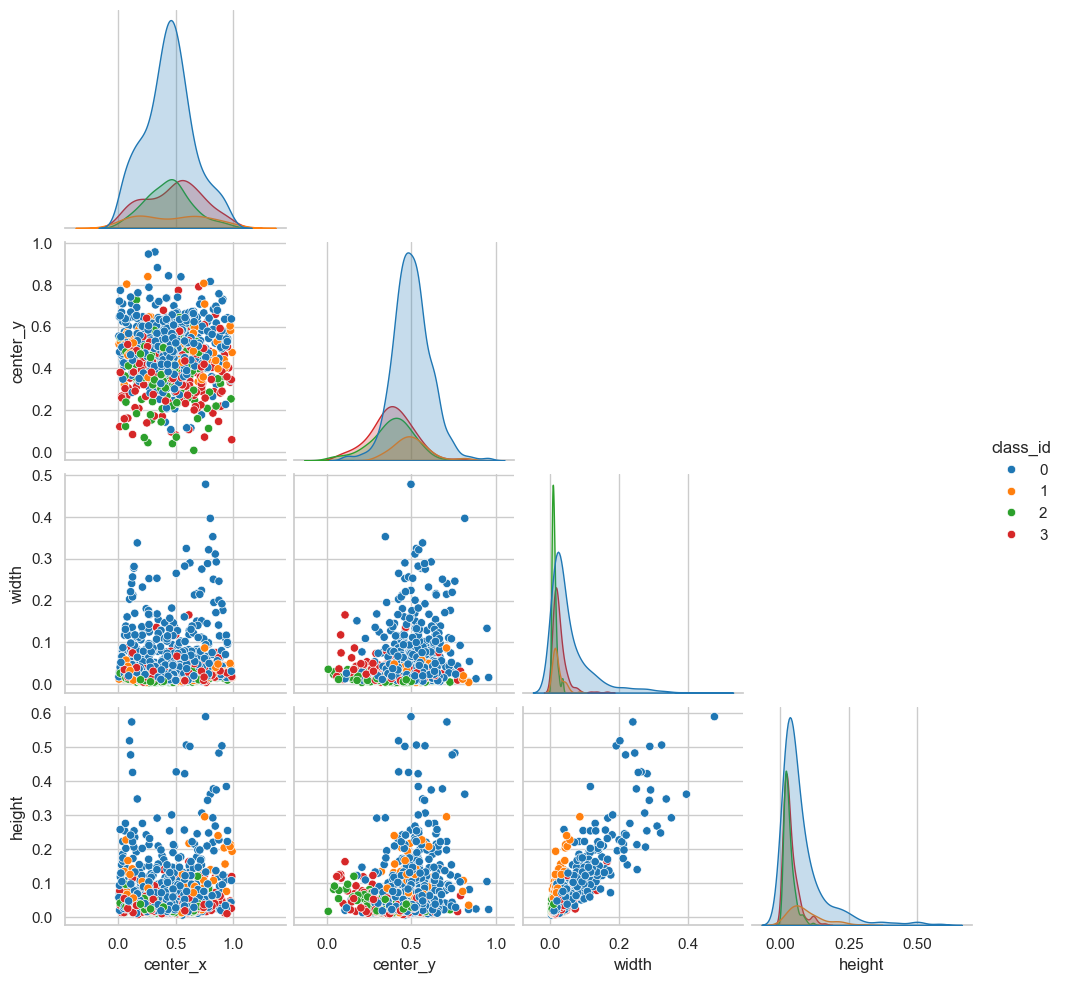

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Categorical Features: Bar Chart
sns.countplot(data=df, x='class_id', hue='class_id', ax=axes[0, 0], palette="viridis", legend=False)
axes[0, 0].set_title("Distribution of Object Classes (Categorical)")
axes[0, 0].set_xlabel("Class ID")
axes[0, 0].set_ylabel("Count")

#Numerical Features: Histogram
sns.histplot(data=df, x='width', bins=50, ax=axes[0, 1], color="skyblue", kde=True)
axes[0, 1].set_title("Distribution of Bounding Box Widths (Numerical)")
axes[0, 1].set_xlabel("Normalized Width")

#Numerical Features: Boxplot
sns.boxplot(data=df, x='class_id', y='height', hue='class_id', ax=axes[1, 0], palette="Set2", legend=False)
axes[1, 0].set_title("Boxplot of Object Heights by Class")
axes[1, 0].set_xlabel("Class ID")
axes[1, 0].set_ylabel("Normalized Height")

#Relationships: Scatter Plot
sns.scatterplot(data=df, x='width', y='height', hue='class_id', ax=axes[1, 1], alpha=0.3, palette="tab10")
axes[1, 1].set_title("Bounding Box Width vs. Height Correlation")
axes[1, 1].set_xlabel("Normalized Width")
axes[1, 1].set_ylabel("Normalized Height")

plt.tight_layout()
plt.show()

#Pair Plot
print("\nPairplot")
sampled_df = df.sample(n=1000, random_state=42)
sns.pairplot(sampled_df[['center_x', 'center_y', 'width', 'height', 'class_id']], hue='class_id', palette="tab10", corner=True)
plt.show()